In [21]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me
import random
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 10000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)




#graphe complet 
W3 = np.ones((a, a)) / a









C:\Users\BONETTI\AppData\Local\Temp\ipykernel_25756\739915216.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


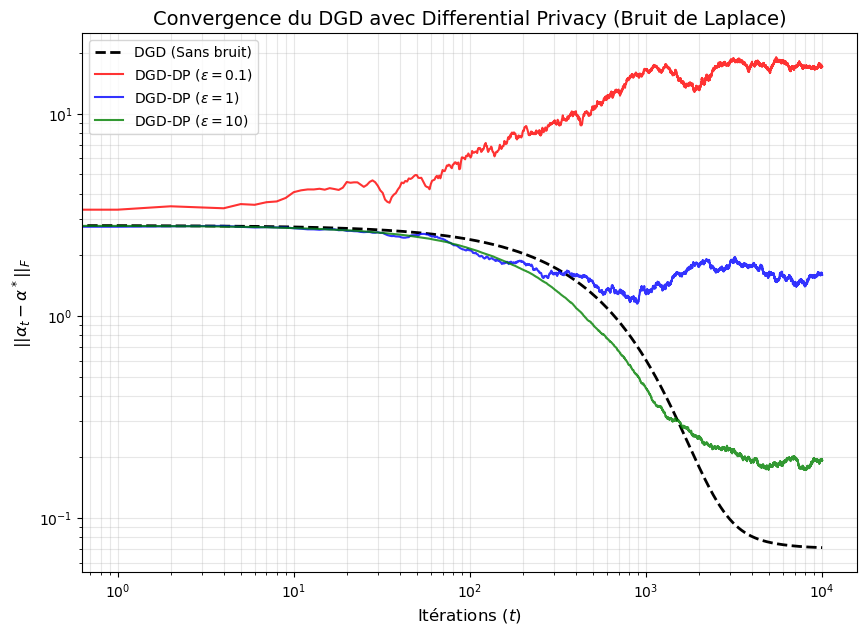

In [22]:

# Epsilon
epsilons = [0.1, 1, 10]

# dans le poly on a ces formules 
def gamma_k(t): return 1 / (1 + 0.001*(t**0.9))   # Pas de consensus
def alpha_k(t): return 0.002 / (1 + 0.001*t)  # Pas de gradient

# Sensibilité du gradient
sensitivity = 0.01

# Matrice cible pour le calcul de l'erreur (alpha_star répété pour les a agents)
alpha_star_matrix = np.tile(alpha_star, (a, 1))

# 
# DGD Classique (Référence sans bruit)
alpha_dgd_simple = np.zeros((a, m))
err_simple = []

# DGD-DP 
dp_runs = {
    eps: {
        'alpha': np.zeros((a, m)),
        'scale': sensitivity / eps, # Échelle du bruit de Laplace 
        'errors': []
    } for eps in epsilons
}


for t in range(n_iter):
    
    # --- A. DGD SIMPLE (SANS BRUIT) ---
    new_alpha_simple = np.zeros_like(alpha_dgd_simple)
    for i in range(a):
        idx_loc = range(i*20, (i+1)*20)
        # Gradient local
        grad_i = (sigma**2/a)*Kmm @ alpha_dgd_simple[i] + \
                 Knm[idx_loc].T @ (Knm[idx_loc] @ alpha_dgd_simple[i] - y[idx_loc]) + \
                 (nu/a)*alpha_dgd_simple[i]
        
        # Mise à jour classique (pas fixe)
        new_alpha_simple[i] = W3[i, :] @ alpha_dgd_simple - 0.001 * grad_i
    alpha_dgd_simple = new_alpha_simple
    err_simple.append(np.linalg.norm(alpha_dgd_simple - alpha_star_matrix, 'fro'))

    # --- B. DGD-DP (AVEC BRUIT POUR CHAQUE EPSILON) ---
    for eps, data in dp_runs.items():
        alpha_c = data['alpha']
        
        # Bruit de Laplace ajouté avant la communication
        # Chaque agent bruite ses paramètres
        chi = alpha_c + np.random.laplace(0, data['scale'], size=(a, m))
        
        new_alpha_dp = np.zeros_like(alpha_c)
        for i in range(a):
            idx_loc = range(i*20, (i+1)*20)
            # Gradient local
            grad_i = (sigma**2/a)*Kmm @ alpha_c[i] + \
                     Knm[idx_loc].T @ (Knm[idx_loc] @ alpha_c[i] - y[idx_loc]) + \
                     (nu/a)*alpha_c[i]
            
            # 2. Mise à jour DGD-DP : Consensus bruité + Descente
            # W3[i, :] @ chi fait la somme pondérée des voisins bruités
            consensus = W3[i, :] @ (chi - alpha_c[i, None])
            
            new_alpha_dp[i] = alpha_c[i] + gamma_k(t) * consensus - alpha_k(t) * grad_i
            
        # Mise à jour de l'état et stockage de l'erreur 
        data['alpha'] = new_alpha_dp
        data['errors'].append(np.linalg.norm(new_alpha_dp - alpha_star_matrix, 'fro'))


plt.figure(figsize=(10, 7))
plt.loglog(err_simple, 'k--', label='DGD (Sans bruit)', linewidth=2)

# Courbes DP
colors = {0.1: 'red', 1: 'blue', 10: 'green'}
for eps, data in dp_runs.items():
    plt.loglog(data['errors'], label=f'DGD-DP ($\epsilon={eps}$)', color=colors[eps], alpha=0.8)

plt.xlabel('Itérations ($t$)', fontsize=12)
plt.ylabel(r'$||\alpha_t - \alpha^*||_F$', fontsize=12)
plt.title('Convergence du DGD avec Differential Privacy (Bruit de Laplace)', fontsize=14)
plt.legend(loc='best', frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.savefig('DGD_DP_Results.pdf')
plt.show()

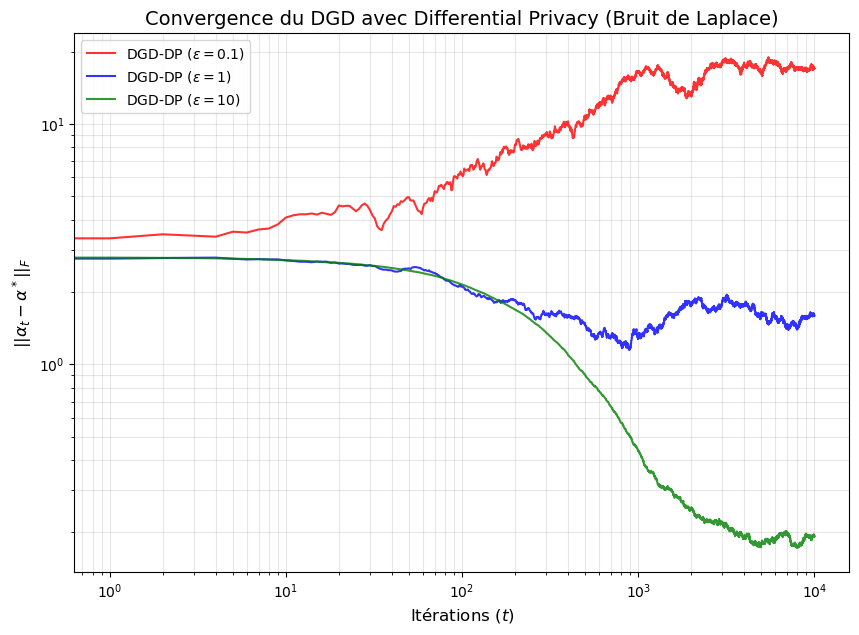

In [23]:

plt.figure(figsize=(10, 7))

colors = {0.1: 'red', 1: 'blue', 10: 'green'}
for eps, data in dp_runs.items():
    plt.loglog(data['errors'], label=f'DGD-DP ($\epsilon={eps}$)', color=colors[eps], alpha=0.8)
plt.xlabel('Itérations ($t$)', fontsize=12)
plt.ylabel(r'$||\alpha_t - \alpha^*||_F$', fontsize=12)
plt.title('Convergence du DGD avec Differential Privacy (Bruit de Laplace)', fontsize=14)
plt.legend(loc='best', frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.savefig('DGD_DP_Results.pdf')
plt.show()

**bonus**


C:\Users\BONETTI\AppData\Local\Temp\ipykernel_25756\3572115149.py:19: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


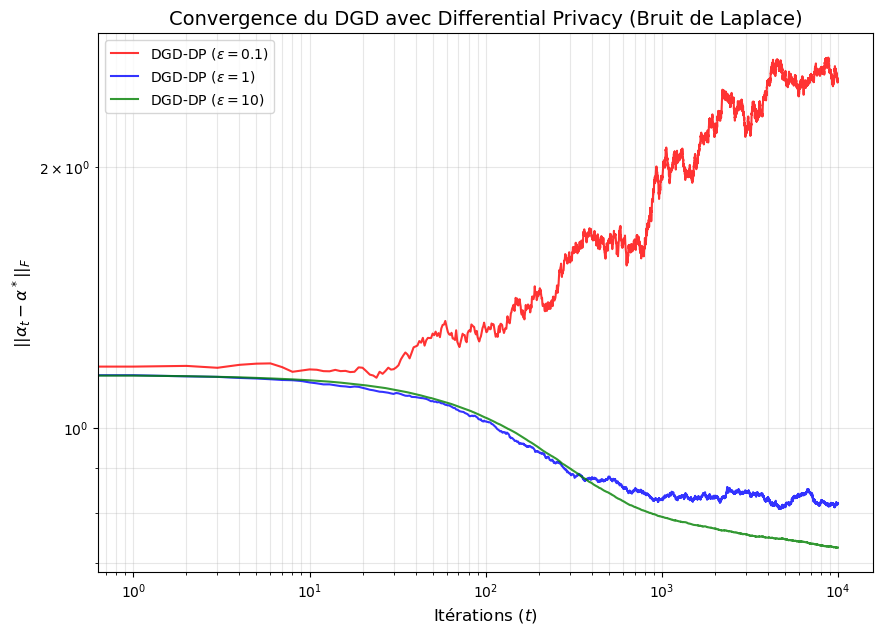

In [24]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me
import random
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 1000, 33, 100
points_per_agent=n//a



sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 10000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)




#graphe complet 
W3 = np.ones((a, a)) / a




# Epsilon demandés
epsilons = [0.1, 1, 10]

def gamma_k(t): return 1 / (1 + 0.001*(t**0.9))   # Pas de consensus
def alpha_k(t): return 0.002 / (1 + 0.001*t)  # Pas de gradient

sensitivity = 0.01

alpha_star_matrix = np.tile(alpha_star, (a, 1))

alpha_dgd_simple = np.zeros((a, m))
err_simple = []

dp_runs = {
    eps: {
        'alpha': np.zeros((a, m)),
        'scale': sensitivity / eps, 
        'errors': []
    } for eps in epsilons
}


for t in range(n_iter):
    
    # --- A. DGD SIMPLE (SANS BRUIT) ---
    new_alpha_simple = np.zeros_like(alpha_dgd_simple)
    for i in range(a):
        idx_loc = range(i*points_per_agent, (i+1)*points_per_agent)
        # Gradient local
        grad_i = (sigma**2/a)*Kmm @ alpha_dgd_simple[i] + \
                 Knm[idx_loc].T @ (Knm[idx_loc] @ alpha_dgd_simple[i] - y[idx_loc]) + \
                 (nu/a)*alpha_dgd_simple[i]
        
        # Mise à jour classique (pas fixe)
        new_alpha_simple[i] = W3[i, :] @ alpha_dgd_simple - 0.001 * grad_i
    alpha_dgd_simple = new_alpha_simple
    dist_simple = [np.linalg.norm(alpha_dgd_simple[i] - alpha_star) for i in range(a)]
    err_simple.append(np.max(dist_simple))
    # --- B. DGD-DP (AVEC BRUIT POUR CHAQUE EPSILON) ---
    for eps, data in dp_runs.items():
        alpha_c = data['alpha']
        
        
        # Chaque agent bruite ses paramètres
        chi = alpha_c + np.random.laplace(0, data['scale'], size=(a, m))
        
        new_alpha_dp = np.zeros_like(alpha_c)
        for i in range(a):
            idx_loc = range(i*points_per_agent, (i+1)*points_per_agent)
            # Gradient local
            grad_i = (sigma**2/a)*Kmm @ alpha_c[i] + \
                     Knm[idx_loc].T @ (Knm[idx_loc] @ alpha_c[i] - y[idx_loc]) + \
                     (nu/a)*alpha_c[i]
            
            # 2. Mise à jour DGD-DP : Consensus bruité + Descente
            # W3[i, :] @ chi fait la somme pondérée des voisins bruités
            consensus = W3[i, :] @ (chi - alpha_c[i, None])
            
            new_alpha_dp[i] = alpha_c[i] + gamma_k(t) * consensus - alpha_k(t) * grad_i
            
        # Mise à jour de l'état et stockage de l'erreur (Norme de Frobenius)
        data['alpha'] = new_alpha_dp
        dist_dp = [np.linalg.norm(new_alpha_dp[i] - alpha_star) for i in range(a)]
        data['errors'].append(np.max(dist_dp))

plt.figure(figsize=(10, 7))

colors = {0.1: 'red', 1: 'blue', 10: 'green'}
for eps, data in dp_runs.items():
    plt.loglog(data['errors'], label=f'DGD-DP ($\epsilon={eps}$)', color=colors[eps], alpha=0.8)

plt.xlabel('Itérations ($t$)', fontsize=12)
plt.ylabel(r'$||\alpha_t - \alpha^*||_F$', fontsize=12)
plt.title('Convergence du DGD avec Differential Privacy (Bruit de Laplace)', fontsize=14)
plt.legend(loc='best', frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.savefig('DGD_DP_Results.pdf')
plt.show()



